In [1]:
from transformers import AutoTokenizer, AutoModel
import torch


from src.LM.embeddings.embedder_preprocess import load_minilm_embedder, prepare_data_minilm_simple
from src.ML.train_NN import train_model, print_NN_input_sample, TextClassifier, DeepTextClassifier

from src.data_loader import load_data
from src.ML.train_NN import train_model
from src.ML.train_NN import train_model_sample_weights
from src.ML.train_NN import train_model_class_weights_and_sampling
from src.ML.train_NN import train_minilm_nn

DATA_PATH = "/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv"
df = load_data(DATA_PATH)

Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...


Category
0    0.727666
1    0.272334
Name: proportion, dtype: float64
using devide: cuda
Loading pretrained MiniLM model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda
Loaded embedding cache.
Saved cache with 694 entries.

Classification Report:
              precision    recall  f1-score   support

           0     0.7431    0.8020    0.7714       101
           1     0.3333    0.2632    0.2941        38

    accuracy                         0.6547       139
   macro avg     0.5382    0.5326    0.5328       139
weighted avg     0.6311    0.6547    0.6409       139

Final Test Accuracy: 0.6547


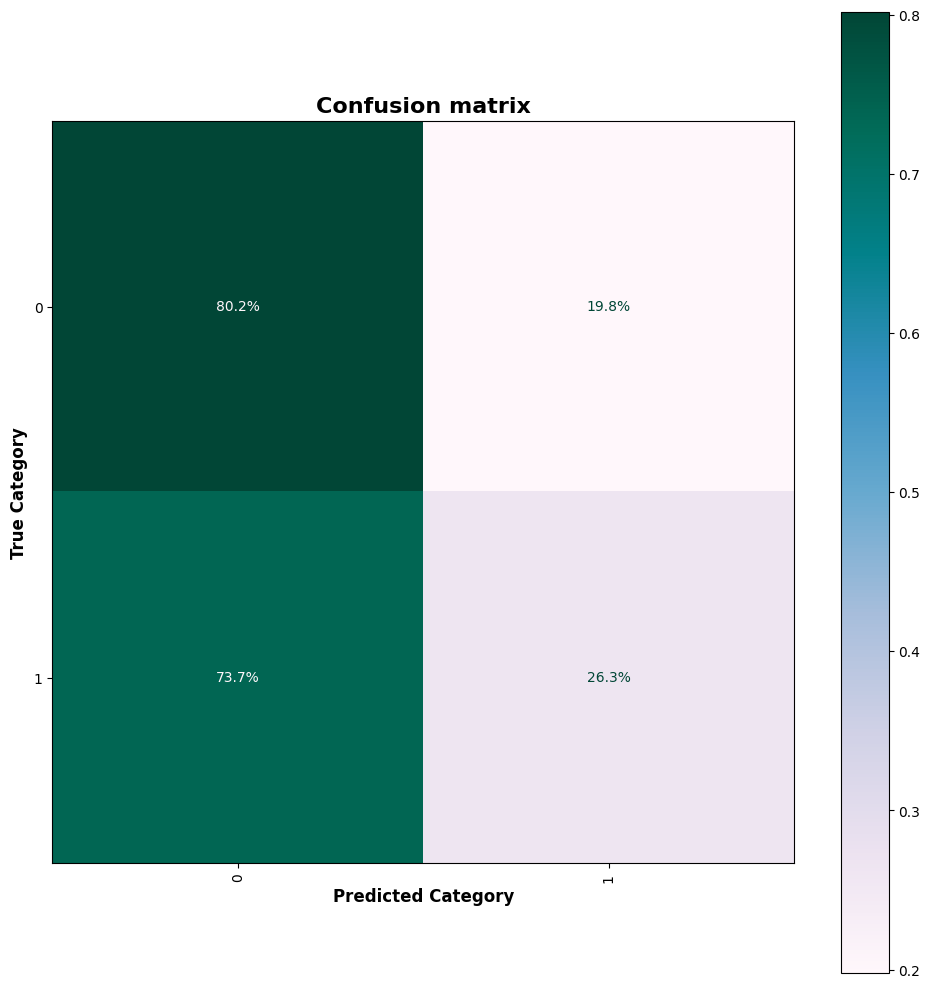

<Figure size 640x480 with 0 Axes>

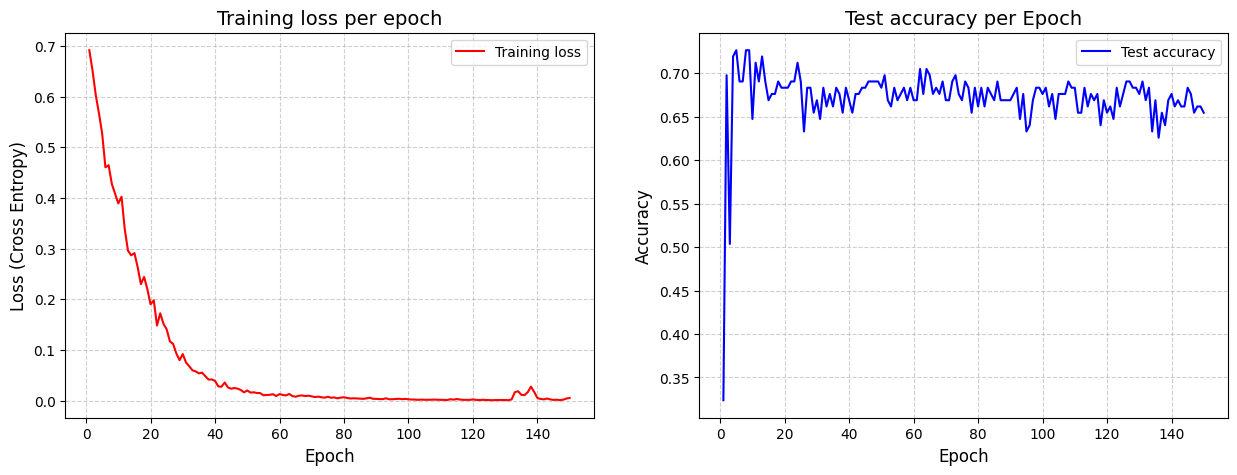

<Figure size 640x480 with 0 Axes>

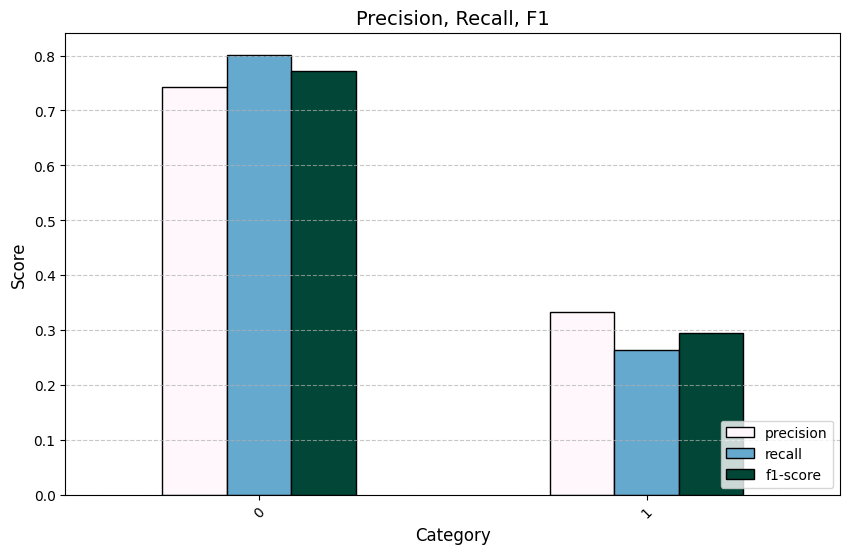

<Figure size 640x480 with 0 Axes>

In [ ]:
print(df["Category"].value_counts(normalize=True))


device = "cuda"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)
minilm_model.eval()  


X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)


# vahy pre batche, pouziva sa sampler

model, class_to_idx, acc = train_model_sample_weights(
    X_train_vec, y_train, X_test_vec, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 128},
    epochs=150,
    lr=0.001
)


Category
0    0.727666
1    0.272334
Name: proportion, dtype: float64
using devide: cuda
Loading pretrained MiniLM model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda
Loaded embedding cache.
Saved cache with 694 entries.
Class weights: tensor([0.6869, 3.6755], device='cuda:0')
              precision    recall  f1-score   support

           0       0.79      0.75      0.77       101
           1       0.42      0.47      0.44        38

    accuracy                           0.68       139
   macro avg       0.61      0.61      0.61       139
weighted avg       0.69      0.68      0.68       139



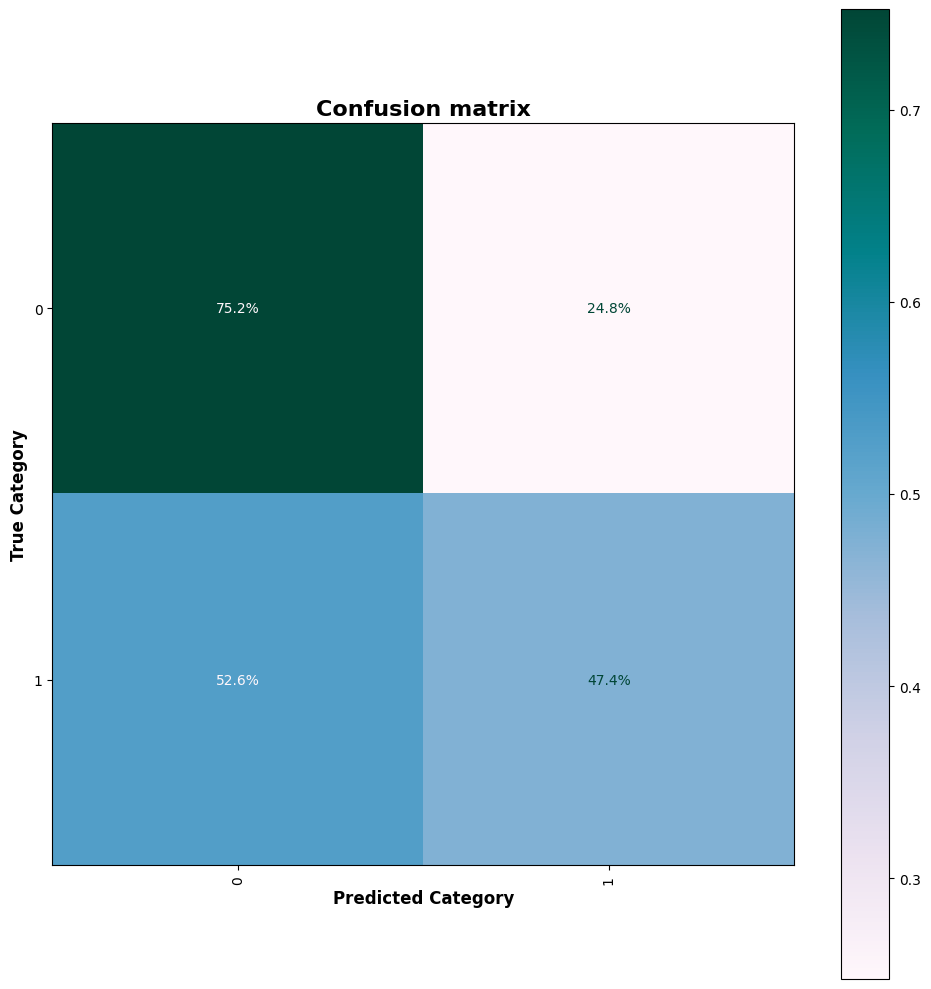

<Figure size 640x480 with 0 Axes>

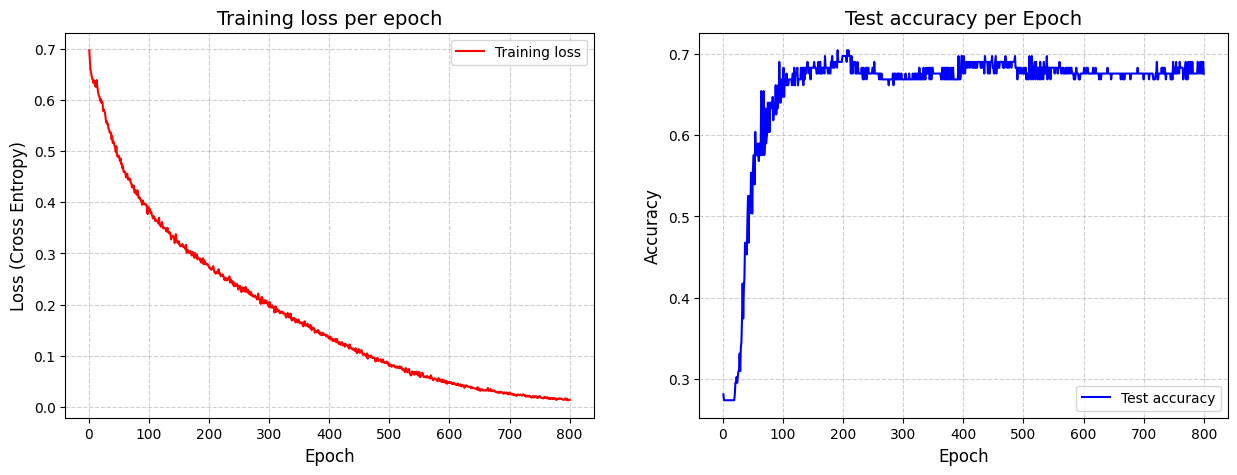

<Figure size 640x480 with 0 Axes>

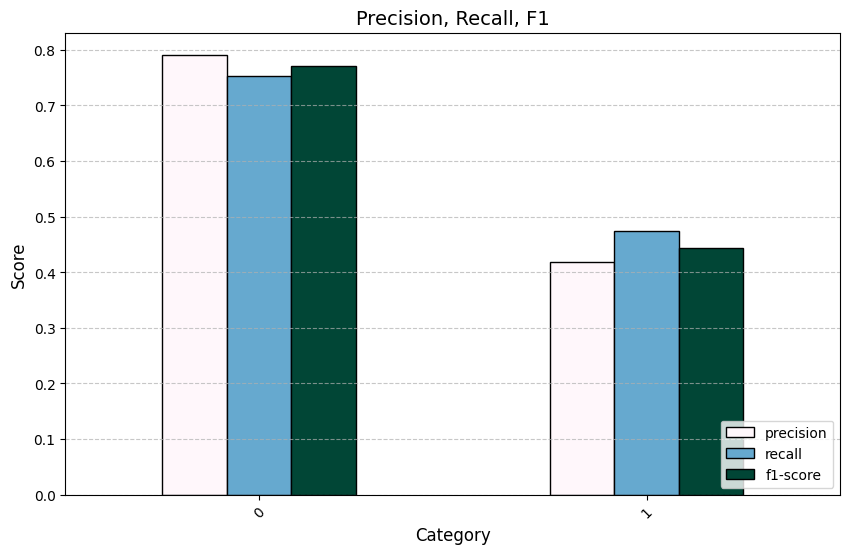

<Figure size 640x480 with 0 Axes>

In [ ]:
print(df["Category"].value_counts(normalize=True))


device = "cuda"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)
minilm_model.eval()  


X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)


# trenovvanie s vahami tried (manualny booster pre triedu 1 je 2)

model, class_to_idx = train_minilm_nn(
     X_train_vec, y_train,
    X_test_vec, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 180},
    epochs=800,
    lr=0.0002
)


Category
0    0.727666
1    0.272334
Name: proportion, dtype: float64
using devide: cuda
Loading pretrained MiniLM model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda
Loaded embedding cache.
Saved cache with 694 entries.
Class weights: tensor([0.6869, 3.6755], device='cuda:0')
              precision    recall  f1-score   support

           0       0.77      0.80      0.79       101
           1       0.41      0.37      0.39        38

    accuracy                           0.68       139
   macro avg       0.59      0.59      0.59       139
weighted avg       0.67      0.68      0.68       139



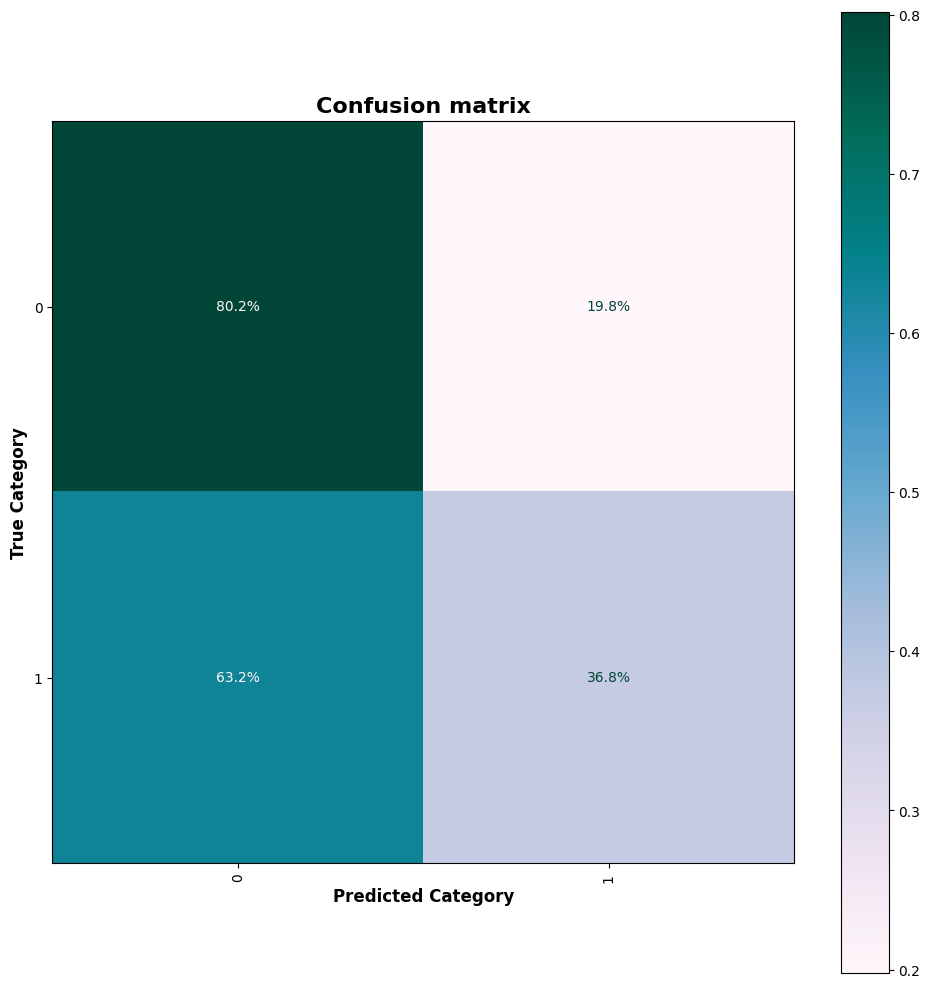

<Figure size 640x480 with 0 Axes>

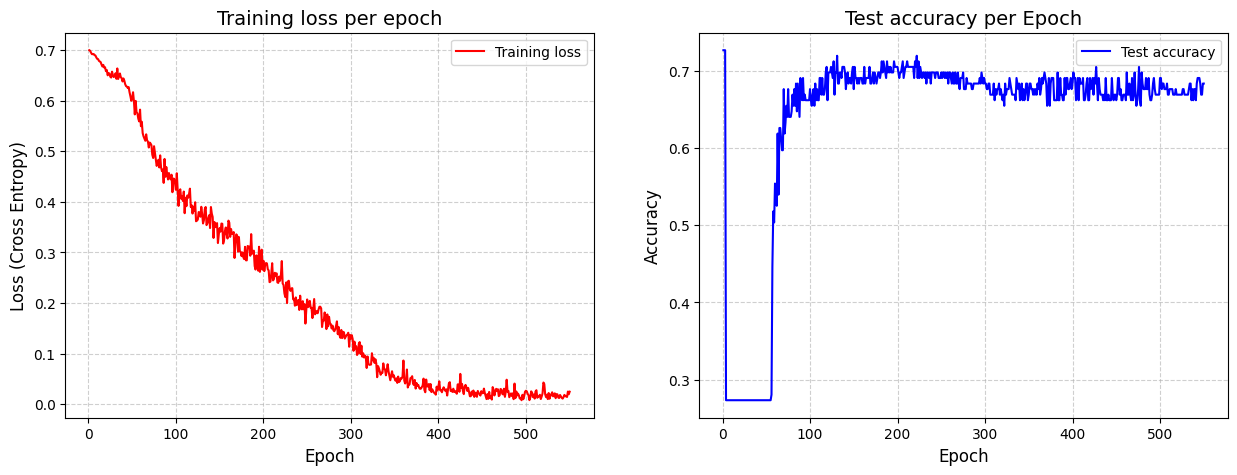

<Figure size 640x480 with 0 Axes>

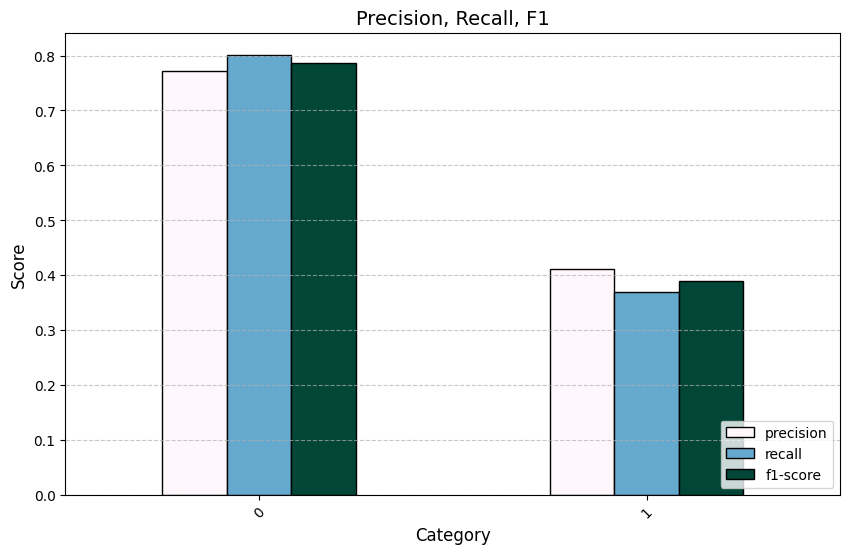

<Figure size 640x480 with 0 Axes>

In [ ]:
print(df["Category"].value_counts(normalize=True))


device = "cuda"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)
minilm_model.eval()  


X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)


# trenovanie s vahami tried (manualny booster pre triedu 1 je 2)

model, class_to_idx = train_minilm_nn(
     X_train_vec, y_train,
    X_test_vec, y_test,
    model_class=DeepTextClassifier,
    model_params={"hidden_dims": [256, 128, 64,32, 16, 8]},
    epochs=550,
    lr=0.0001
)


Category
0    0.727666
1    0.272334
Name: proportion, dtype: float64
using devide: cuda
Loading pretrained MiniLM model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda
Loaded embedding cache.
Saved cache with 694 entries.

Classification Report:
              precision    recall  f1-score   support

           0     0.8488    0.7228    0.7807       101
           1     0.4717    0.6579    0.5495        38

    accuracy                         0.7050       139
   macro avg     0.6603    0.6903    0.6651       139
weighted avg     0.7457    0.7050    0.7175       139



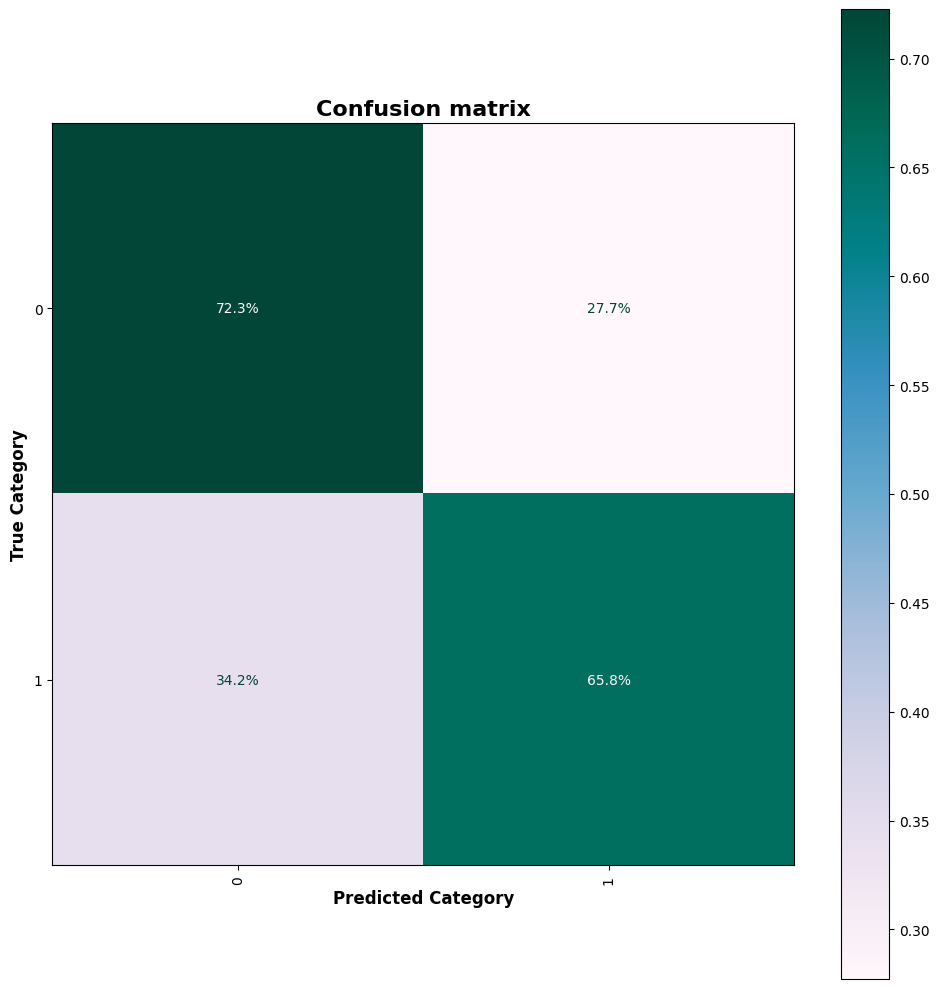

<Figure size 640x480 with 0 Axes>

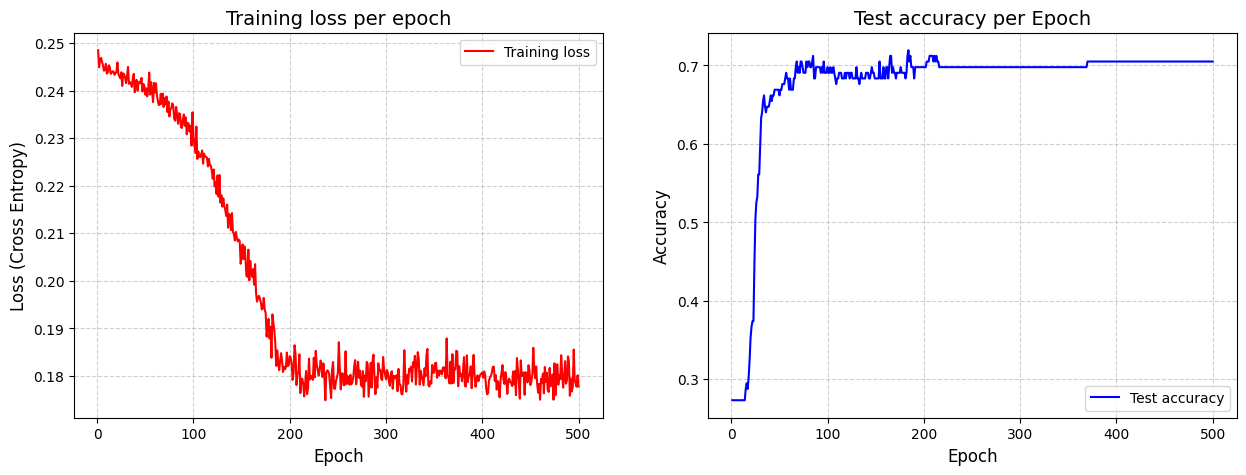

<Figure size 640x480 with 0 Axes>

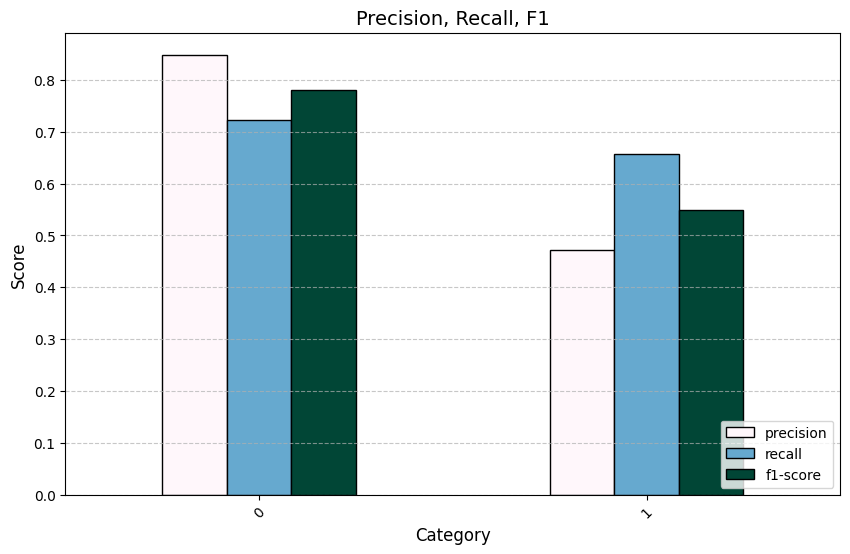

<Figure size 640x480 with 0 Axes>

In [ ]:
from src.ML.train_NN import train_nn_with_focal_loss
from torch.utils.data import TensorDataset, DataLoader
import torch 


print(df["Category"].value_counts(normalize=True))


device = "cuda"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)
minilm_model.eval()  


X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)

X_train_tensor = torch.tensor(X_train_vec, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.map({cls: i for i, cls in enumerate(sorted(set(y_train)))}).values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_vec, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.map({cls: i for i, cls in enumerate(sorted(set(y_train)))}).values, dtype=torch.long)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
val_ds = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)


input_dim = X_train_vec.shape[1]
output_dim = len(set(y_train))
model = DeepTextClassifier(input_dim=input_dim, output_dim=output_dim, hidden_dims=[256, 128, 64])

# FOCAL LOSS
# modifikacia cross entropy loss specialne pre nevyvazene datasety
# pri treningu je focus na 'tazke' vzorky
# predikovana pravdepodobnost zavisi od parametra alpha (vaha pre kazdu triedu - vyrovnava imbalanc) a gamma (focusing parameter)
# ak gamma = 0, focal loss = standardny cross entropy loss


trained_model = train_nn_with_focal_loss(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=500,
    lr=1e-5,
    alpha=torch.tensor([1.0, 2.5], device=device),  
    gamma=2.0,
    use_scheduler=True,
    device=device
)
